# Per-character TF-IDF: 10 main POV characters

Mirrors the house-level TF-IDF but at the **character** level. Each character's document = `bio + quotes`. IDF is taken over the 10-character corpus so a word that appears in every character's writing gets zero weight; a word distinctive to one character (e.g. Daenerys' Valyrian terms, Tyrion's wine vocabulary, Davos' Flea-Bottom slang) rises to the top.

Character names are filtered from tokens — otherwise `tyrion`, `cersei`, etc. dominate trivially. House names are kept (they're informative: 'lannister' is a distinctive Tyrion token, 'targaryen' for Daenerys).

Reads `characters_enriched_v2.csv`, `characters_bio.csv`, and `characters_quotes.csv`.

In [13]:
import math
import os
import string
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

for pkg in ['punkt', 'punkt_tab', 'stopwords']:
    try:
        nltk.data.find(f'tokenizers/{pkg}')
    except LookupError:
        try:
            nltk.download(pkg, quiet=True)
        except Exception:
            pass

stop_words = set(stopwords.words('english'))


## Load data and pick the 10 main characters
Canonical POV characters from Books 1-5, spanning multiple houses and regions.

In [14]:
df = pd.read_csv('characters_enriched_v2.csv').fillna('')
bios_df = pd.read_csv('characters_bio.csv').fillna('')
bios = dict(zip(bios_df['ID'], bios_df['bio']))

if os.path.exists('characters_quotes.csv'):
    quotes_df = pd.read_csv('characters_quotes.csv').fillna('')
    quotes_df = quotes_df[quotes_df['speaker_id'].str.len() > 0]
    quotes = quotes_df.groupby('speaker_id')['quote'].apply(lambda s: ' '.join(s)).to_dict()
    print(f'Loaded {len(quotes_df)} quotes attributed to {len(quotes)} distinct speakers')
else:
    quotes = {}
    print('characters_quotes.csv not found — running on bios only')

MAIN_CHARACTERS = [
    'Eddard_Stark',
    'Tyrion_Lannister',
    'Cersei_Lannister',
    'Jaime_Lannister',
    'Jon_Snow',
    'Daenerys_Targaryen',
    'Sansa_Stark',
    'Bran_Stark',
    'Petyr_Baelish',     # Littlefinger — Vale, schemer
    'Theon_Greyjoy',     # Iron Islands POV
]

valid_ids = set(df['ID'])
missing = [c for c in MAIN_CHARACTERS if c not in valid_ids]
if missing:
    print(f'WARNING: not found in v2 character set: {missing}')
MAIN_CHARACTERS = [c for c in MAIN_CHARACTERS if c in valid_ids]
name_by_id = dict(zip(df['ID'], df['name']))

for cid in MAIN_CHARACTERS:
    bio_len = len(bios.get(cid, ''))
    q_len = len(quotes.get(cid, ''))
    print(f'  {name_by_id[cid]:25s}  bio: {bio_len:>6} chars   quotes: {q_len:>5} chars')


Loaded 4275 quotes attributed to 505 distinct speakers
  Eddard Stark               bio:  11057 chars   quotes: 17145 chars
  Tyrion Lannister           bio:  19604 chars   quotes: 49279 chars
  Cersei Lannister           bio:  26347 chars   quotes: 35129 chars
  Jaime Lannister            bio:  21965 chars   quotes: 43061 chars
  Jon Snow                   bio:  26336 chars   quotes: 51133 chars
  Daenerys Targaryen         bio:  39275 chars   quotes: 31221 chars
  Sansa Stark                bio:  17574 chars   quotes: 27792 chars
  Brandon Stark              bio:  14227 chars   quotes: 16699 chars
  Petyr Baelish              bio:  17534 chars   quotes: 14986 chars
  Theon Greyjoy              bio:  17155 chars   quotes: 21354 chars


## Build per-character corpus + tokenize
Same tokenization as the house TF-IDF: lowercase, NLTK word_tokenize, drop stopwords/punctuation, keep alpha-only. **Plus a character-name filter** built from every token appearing in any character's display name.

In [15]:
character_name_tokens = set()
for nm in df['name']:
    for part in str(nm).lower().split():
        cleaned = part.strip(string.punctuation)
        if cleaned and cleaned.isalpha() and len(cleaned) > 2:
            character_name_tokens.add(cleaned)
print(f'Character-name filter: {len(character_name_tokens)} tokens')

from nltk.collocations import BigramCollocationFinder, BigramAssocMeasures
from nltk.tokenize import MWETokenizer


def base_tokenize(text):
    return [w for w in word_tokenize(text.lower())
            if w not in stop_words
            and w not in string.punctuation
            and w.isalpha()
            and w not in character_name_tokens
            and len(w) > 2]


# Discover collocations on the whole AWOIAF corpus, not just the 10 mains.
# Larger corpus → more stable bigram statistics. Mirrors week 7 of the course.
all_tokens = []
for cid in df['ID']:
    text = bios.get(cid, '') + ' ' + quotes.get(cid, '')
    if text.strip():
        all_tokens.extend(base_tokenize(text))

bigram_measures = BigramAssocMeasures()
finder = BigramCollocationFinder.from_words(all_tokens)
finder.apply_freq_filter(30)
collocations = finder.nbest(bigram_measures.chi_sq, 100)
print(f'Found {len(collocations)} significant bigrams. Top 15:')
for w1, w2 in collocations[:15]:
    print(f'  {w1}_{w2}')

mwe = MWETokenizer(collocations, separator='_')


def tokenize(text):
    return mwe.tokenize(base_tokenize(text))


char_tokens = {}
for cid in MAIN_CHARACTERS:
    text = bios.get(cid, '') + ' ' + quotes.get(cid, '')
    char_tokens[cid] = tokenize(text)

for cid in MAIN_CHARACTERS:
    print(f'  {name_by_id[cid]:25s} {len(char_tokens[cid]):>6} tokens')


Character-name filter: 3033 tokens
Found 100 significant bigrams. Top 15:
  television_adaptation
  moat_cailin
  game_thrones
  casterly_rock
  vaes_dothrak
  deepwood_motte
  seastone_chair
  adaptation_game
  whispering_wood
  thrones_portrayed
  stony_shore
  haunted_forest
  valyrian_steel
  iron_throne
  brotherhood_banners
  Eddard Stark                1592 tokens
  Tyrion Lannister            4147 tokens
  Cersei Lannister            3576 tokens
  Jaime Lannister             3663 tokens
  Jon Snow                    4811 tokens
  Daenerys Targaryen          4478 tokens
  Sansa Stark                 2650 tokens
  Brandon Stark               2066 tokens
  Petyr Baelish               1825 tokens
  Theon Greyjoy               2293 tokens


## Compute TF, IDF, TF-IDF
TF: term frequency normalized by document length. IDF: log(N / docs containing the word), N=10 here. So a word that appears in all 10 characters gets IDF=0 and TF-IDF=0 — distinctive words rise.

In [16]:
tf_char = {}
for cid, tokens in char_tokens.items():
    if not tokens:
        tf_char[cid] = {}
        continue
    counts = Counter(tokens)
    total = len(tokens)
    tf_char[cid] = {w: c / total for w, c in counts.items()}

N = len(char_tokens)
doc_freq = Counter()
for tokens in char_tokens.values():
    for w in set(tokens):
        doc_freq[w] += 1
idf = {w: math.log(N / doc_freq[w]) for w in doc_freq}

tfidf_char = {cid: {w: tf * idf.get(w, 0) for w, tf in vals.items()}
              for cid, vals in tf_char.items()}

# Sanity: top 10 for each character
TOP = 10
for cid in MAIN_CHARACTERS:
    top = sorted(tfidf_char[cid].items(), key=lambda x: x[1], reverse=True)[:TOP]
    print(f'\n{name_by_id[cid]}:')
    for w, s in top:
        print(f'  {s:.5f}  {w}')



Eddard Stark:
  0.00868  leech
  0.00868  wraiths
  0.00708  crannogman
  0.00607  speech
  0.00607  memories
  0.00607  vowed
  0.00607  mist
  0.00454  stallion
  0.00345  proud
  0.00345  faithful

Tyrion Lannister:
  0.00444  duck
  0.00333  clansmen
  0.00310  griff
  0.00310  volantis
  0.00278  imp
  0.00222  reigned
  0.00222  tool
  0.00222  sounds
  0.00199  coin
  0.00167  manse

Cersei Lannister:
  0.00270  intends
  0.00270  sins
  0.00258  accusations
  0.00258  morrows
  0.00239  grace
  0.00193  valonqar
  0.00193  dromonds
  0.00193  longtable
  0.00193  septas
  0.00193  novices

Jaime Lannister:
  0.00377  coz
  0.00251  brave_companions
  0.00230  swore
  0.00200  obey
  0.00195  casterly_rock
  0.00189  kingslayer
  0.00189  warden
  0.00189  camps
  0.00189  castamere
  0.00189  raventree

Jon Snow:
  0.00457  wildlings
  0.00425  wildling
  0.00335  magnar
  0.00301  recruits
  0.00301  eastwatch
  0.00248  crow
  0.00239  rangers
  0.00239  eagle
  0.00239  gia

## Word clouds — one per character
2 × 5 grid in the canonical reading order.

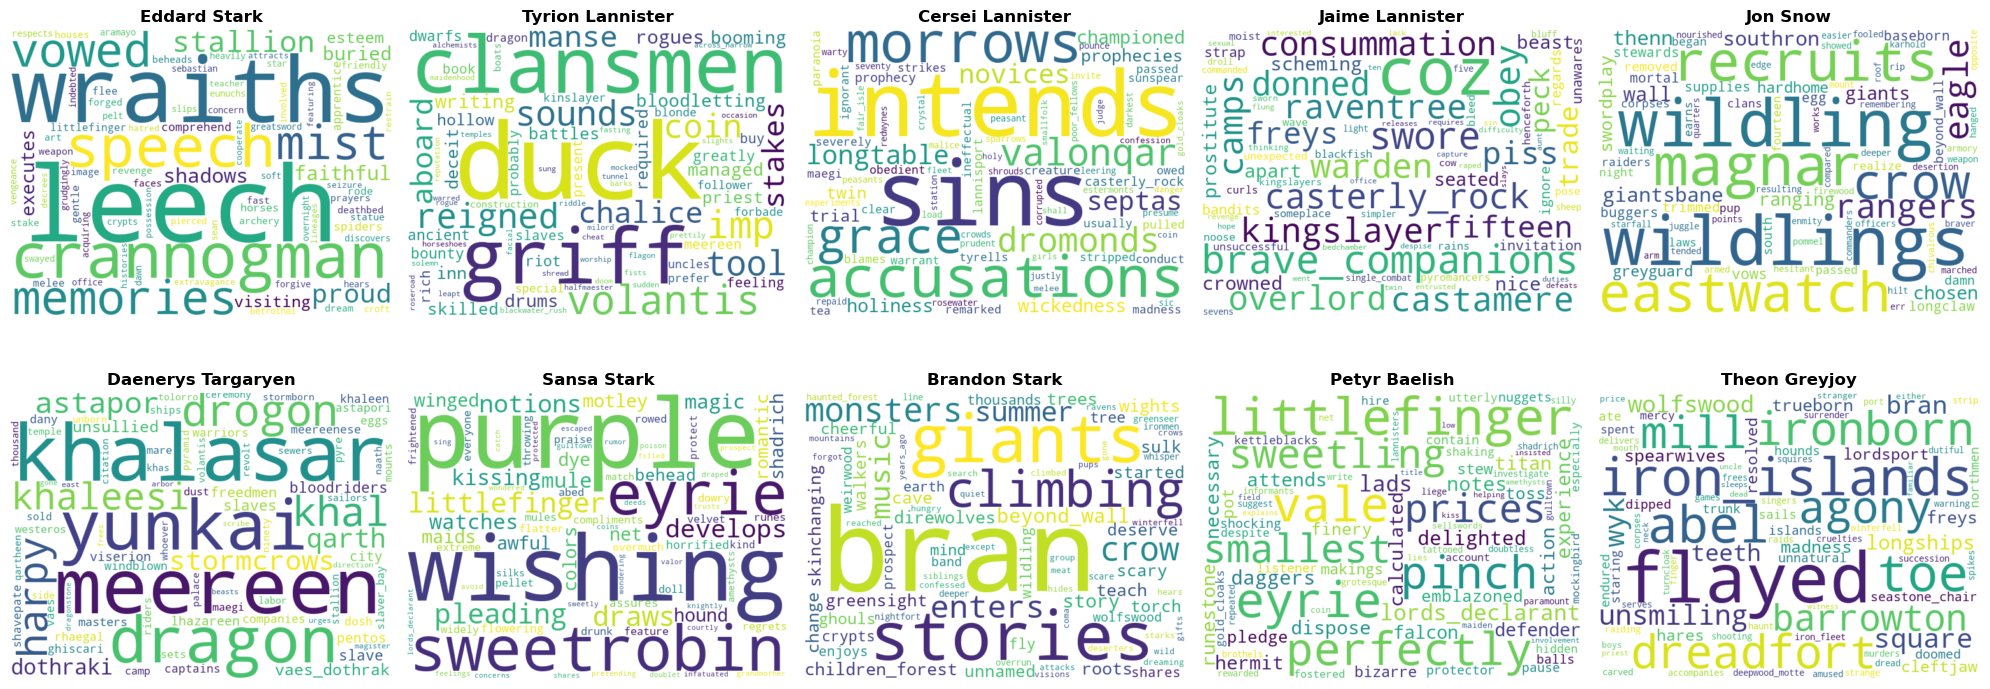

In [17]:
n_cols = 5
n_rows = math.ceil(len(MAIN_CHARACTERS) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for ax, cid in zip(axes, MAIN_CHARACTERS):
    scores = tfidf_char[cid]
    if not scores:
        ax.set_title(f'{name_by_id[cid]}\n(no text)')
        ax.set_axis_off()
        continue
    wc = WordCloud(width=600, height=450, background_color='white',
                   colormap='viridis', max_words=80, prefer_horizontal=0.9)
    wc.generate_from_frequencies(scores)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(name_by_id[cid], fontsize=12, fontweight='bold')
    ax.set_axis_off()

for ax in axes[len(MAIN_CHARACTERS):]:
    ax.set_axis_off()

plt.tight_layout()
plt.show()


## Distinctiveness table
Top-5 TF-IDF tokens for each character side-by-side. Quick scan for cross-character contrasts.

In [18]:
rows = []
for cid in MAIN_CHARACTERS:
    top5 = sorted(tfidf_char[cid].items(), key=lambda x: x[1], reverse=True)[:5]
    rows.append({'character': name_by_id[cid],
                 **{f'top_{i+1}': w for i, (w, _) in enumerate(top5)}})
print(pd.DataFrame(rows).to_string(index=False))


         character        top_1            top_2       top_3    top_4         top_5
      Eddard Stark        leech          wraiths  crannogman   speech      memories
  Tyrion Lannister         duck         clansmen       griff volantis           imp
  Cersei Lannister      intends             sins accusations  morrows         grace
   Jaime Lannister          coz brave_companions       swore     obey casterly_rock
          Jon Snow    wildlings         wildling      magnar recruits     eastwatch
Daenerys Targaryen     khalasar          meereen      yunkai   dragon        drogon
       Sansa Stark       purple          wishing  sweetrobin    eyrie  littlefinger
     Brandon Stark         bran          stories      giants climbing      monsters
     Petyr Baelish littlefinger            eyrie        vale    pinch     perfectly
     Theon Greyjoy       flayed     iron_islands         toe     abel      ironborn
